# Deep Learning for Multi-Horizon Household Power Forecasting
**Master's Thesis Defense Evaluation & Reproducibility Notebook**

This notebook transparently loads pre-trained models from the 24-hour and 168-hour horizon suites and evaluates their performance on the exact canonical test set in the physical scale (Kilowatts).


In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Executing on device: {device}")


Executing on device: cuda


In [2]:
# Dataset Configuration
# Kaggle path: /kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt
CSV_PATH = "../data/household_power_consumption.txt" 
if not os.path.exists(CSV_PATH):
    CSV_PATH = "/kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt"

def prepare_data(csv_path, lookback, horizon, batch_size=64):
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path, sep=';', 
                     parse_dates={'Datetime': ['Date', 'Time']}, 
                     infer_datetime_format=True, 
                     low_memory=False, 
                     na_values=['?'],
                     dayfirst=True)
    df.set_index('Datetime', inplace=True)
    df = df.astype(float)
    df.fillna(method='ffill', inplace=True)
    df = df.resample('1h').mean()
    df.fillna(method='ffill', inplace=True)

    # Time covariates
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek
    df['Month'] = df.index.month - 1
    
    df['h_sin'] = np.sin(2 * np.pi * df['Hour'] / 24.0)
    df['h_cos'] = np.cos(2 * np.pi * df['Hour'] / 24.0)
    df['d_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7.0)
    df['d_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7.0)
    df['m_sin'] = np.sin(2 * np.pi * (df['Month']+1) / 12.0)
    df['m_cos'] = np.cos(2 * np.pi * (df['Month']+1) / 12.0)
    
    # Train/Val/Test split (70% / 10% / 20%)
    n = len(df)
    train_end = int(n * 0.7)
    val_end = int(n * 0.8)
    
    train_df = df.iloc[:train_end]
    test_df = df.iloc[val_end:]
    
    # Scale only based on training set
    feature_cols = [c for c in df.columns if c not in ['Hour', 'DayOfWeek', 'Month', 'h_sin', 'h_cos', 'd_sin', 'd_cos', 'm_sin', 'm_cos']]
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols])
    
    # Process Test Set
    X_test_raw = test_df[feature_cols].values
    X_test_scaled = scaler.transform(X_test_raw)
    cal_test = test_df[['Hour', 'DayOfWeek', 'Month']].values
    cyc_test = test_df[['h_sin', 'h_cos', 'd_sin', 'd_cos', 'm_sin', 'm_cos']].values

    X_seq_raw, X_seq_scaled, X_cal, X_cyc, Y_seq_raw, Y_seq_scaled = [], [], [], [], [], []
    for i in range(len(test_df) - lookback - horizon + 1):
        X_seq_raw.append(X_test_raw[i:i+lookback])
        X_seq_scaled.append(X_test_scaled[i:i+lookback])
        X_cal.append(cal_test[i:i+lookback])
        X_cyc.append(cyc_test[i:i+lookback])
        Y_seq_raw.append(X_test_raw[i+lookback:i+lookback+horizon])
        Y_seq_scaled.append(X_test_scaled[i+lookback:i+lookback+horizon])

    import torch.utils.data as data
    class TSData(data.Dataset):
        def __init__(self, *arrays):
            self.arrays = arrays
        def __len__(self):
            return len(self.arrays[0])
        def __getitem__(self, idx):
            return tuple(torch.tensor(arr[idx], dtype=torch.float) for arr in self.arrays)
            
    test_dataset = TSData(X_seq_raw, X_seq_scaled, X_cal, X_cyc, Y_seq_raw, Y_seq_scaled)
    test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return test_loader, scaler


In [3]:
# ==========================================
# Common Deep Learning Components
# ==========================================
import math

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(self.num_features))
            self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def forward(self, x, mode: str, mean=None, stdev=None):
        if mode == 'norm':
            mean = torch.mean(x, dim=1, keepdim=True).detach()
            stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - mean) / stdev
            if self.affine:
                x = x * self.affine_weight + self.affine_bias
            return x, mean, stdev
        elif mode == 'denorm':
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            x = x * stdev + mean
            return x

class TemporalEmbedding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.hour_embed = nn.Embedding(24, d_model)
        self.weekday_embed = nn.Embedding(7, d_model)
        self.month_embed = nn.Embedding(12, d_model)
        
    def forward(self, temporal_patches):
        hour_x = self.hour_embed(temporal_patches[:, :, 0])
        weekday_x = self.weekday_embed(temporal_patches[:, :, 1])
        month_x = self.month_embed(temporal_patches[:, :, 2])
        return hour_x + weekday_x + month_x

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class Flatten_Head(nn.Module):
    def __init__(self, individual: bool, n_vars: int, head_nf: int, target_window: int, head_dropout=0.0):
        super().__init__()
        self.individual = individual
        self.n_vars = n_vars
        if self.individual:
            self.linears = nn.ModuleList([nn.Linear(head_nf, target_window) for _ in range(self.n_vars)])
            self.dropouts = nn.ModuleList([nn.Dropout(head_dropout) for _ in range(self.n_vars)])
        else:
            self.dropout = nn.Dropout(head_dropout)
            self.linear = nn.Linear(head_nf, target_window)

    def forward(self, x):
        x = x.reshape(x.size(0), x.size(1), -1)
        if self.individual:
            x_out = []
            for i in range(self.n_vars):
                z = self.dropouts[i](x[:, i, :])
                x_out.append(self.linears[i](z))
            x = torch.stack(x_out, dim=1)
        else:
            x = self.dropout(x)
            x = self.linear(x)
        return x


In [4]:
# ==========================================
# 24-Hour Horizon Models
# ==========================================
class CNN_BiLSTM(nn.Module):
    def __init__(self, num_targets=7, forecast_horizon=24, cnn_filters=64, lstm_hidden=64):
        super(CNN_BiLSTM, self).__init__()
        self.num_targets = num_targets
        self.forecast_horizon = forecast_horizon
        
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_targets, out_channels=cnn_filters, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.lstm = nn.LSTM(
            input_size=cnn_filters, 
            hidden_size=lstm_hidden, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True
        )
        
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, forecast_horizon * num_targets)
        )
        
    def forward(self, x_targets, x_calendar=None):
        x = x_targets.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        pred = self.fc(last_out)
        return pred.view(-1, self.forecast_horizon, self.num_targets)

class SOTAForecastingModel(nn.Module):
    def __init__(self, num_targets=7, patch_len_1=8, patch_len_2=24, stride=8, 
                 lookback=96, d_model=64, d_channel=256, forecast_horizon=24):
        super().__init__()
        self.num_targets = num_targets
        self.patch_len_1 = patch_len_1
        self.patch_len_2 = patch_len_2
        self.stride = stride
        self.lookback = lookback
        self.d_model = d_model
        self.d_channel = d_channel
        self.forecast_horizon = forecast_horizon
        
        self.num_patches = (lookback - patch_len_1) // stride + 1
        self.revin = RevIN(num_features=num_targets)
        
        self.embed_1 = nn.Linear(patch_len_1, d_model)
        self.embed_2 = nn.Linear(patch_len_2, d_model)
        self.calendar_embed = nn.Linear(6, 2 * d_model)
        
        self.gru = nn.GRU(d_model * 2, d_model, batch_first=True, bidirectional=True)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model * 2, nhead=4, dim_feedforward=d_model * 4, batch_first=True, dropout=0.2),
            num_layers=2
        )
        
        self.flat_dim = self.num_patches * (d_model * 2)
        self.channel_proj = nn.Linear(self.flat_dim, d_channel)
        
        self.cross_var_attn = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_channel, nhead=8, dim_feedforward=d_channel * 2, batch_first=True, dropout=0.2),
            num_layers=1
        )
        
        self.predict_head = nn.Linear(d_channel, forecast_horizon)
        
    def forward(self, x_targets, x_calendar):
        batch_size = x_targets.shape[0]
        x_norm, mean, stdev = self.revin(x_targets, mode='norm')
        x_ci = x_norm.transpose(1, 2).reshape(batch_size * self.num_targets, -1, 1)
        
        patches_1 = x_ci.unfold(dimension=1, size=self.patch_len_1, step=self.stride).squeeze(2)
        pad_len = self.patch_len_2 - self.patch_len_1
        x_ci_padded = torch.cat([x_ci[:, :1, :].repeat(1, pad_len, 1), x_ci], dim=1)
        patches_2 = x_ci_padded.unfold(dimension=1, size=self.patch_len_2, step=self.stride).squeeze(2)
        
        embed_1 = self.embed_1(patches_1)
        embed_2 = self.embed_2(patches_2)
        feat_in = torch.cat([embed_1, embed_2], dim=-1)
        
        patch_indices = [i * self.stride + self.patch_len_1 - 1 for i in range(self.num_patches)]
        cal_patched = x_calendar[:, patch_indices, :]
        cal_feat = self.calendar_embed(cal_patched.float())
        cal_feat = cal_feat.repeat_interleave(self.num_targets, dim=0)
        
        feat_in = feat_in + cal_feat
        gru_out, _ = self.gru(feat_in)
        tf_out = self.transformer(gru_out)
        
        tf_flat = tf_out.reshape(batch_size * self.num_targets, -1)
        channel_feats = tf_flat.reshape(batch_size, self.num_targets, -1)
        channel_feats = self.channel_proj(channel_feats)
        
        cross_out = self.cross_var_attn(channel_feats)
        preds = self.predict_head(cross_out)
        preds = preds.transpose(1, 2)
        
        pred_final = self.revin(preds, mode='denorm', mean=mean, stdev=stdev)
        return pred_final

# ==========================================
# 168-Hour Horizon Models
# ==========================================
class AdvancedPatchTST(nn.Module):
    def __init__(self, c_in=7, context_window=336, target_window=168, 
                 patch_len=16, stride=8, d_model=128, n_heads=8, 
                 n_layers=3, d_ff=256, dropout=0.2, head_dropout=0.2):
        super().__init__()
        self.c_in = c_in
        self.target_window = target_window
        self.patch_len = patch_len
        self.stride = stride
        self.revin_layer = RevIN(c_in)
        self.patch_num = int((context_window - patch_len)/stride + 1)
        self.padding_patch_layer = nn.ReplicationPad1d((0, stride)) 
        self.patch_num += 1
        
        self.value_embedding = nn.Linear(patch_len, d_model, bias=False)
        self.position_encoding = PositionalEncoding(d_model, max_len=1024)
        self.temporal_embedding = TemporalEmbedding(d_model)
        self.dropout = nn.Dropout(dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, 
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = Flatten_Head(False, c_in, d_model * self.patch_num, target_window, head_dropout=head_dropout)

    def forward(self, x, temporal):
        x, mean, stdev = self.revin_layer(x, 'norm')
        x = x.permute(0, 2, 1) 
        x = self.padding_patch_layer(x)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        batch_size = x.size(0)
        x = x.reshape(batch_size * self.c_in, self.patch_num, self.patch_len)
        
        temporal_pad = self.padding_patch_layer(temporal.permute(0, 2, 1).float())
        temporal_unfold = temporal_pad.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        temporal_patches = temporal_unfold[:, :, :, -1].permute(0, 2, 1).long()
        
        temp_emb = self.temporal_embedding(temporal_patches).unsqueeze(1).repeat(1, self.c_in, 1, 1)
        temp_emb = temp_emb.reshape(batch_size * self.c_in, self.patch_num, -1)
        
        x = self.value_embedding(x) + temp_emb
        x = self.position_encoding(x)
        x = self.dropout(x)
        x = self.encoder(x)
        
        x = x.reshape(batch_size, self.c_in, self.patch_num, -1)
        x = self.head(x).permute(0, 2, 1)
        x = self.revin_layer(x, 'denorm', mean=mean, stdev=stdev)
        return x

class iTransformer(nn.Module):
    '''iTransformer with Calendar Embeddings as Channels/Tokens'''
    def __init__(self, c_in=7, lookback=336, forecast_horizon=168, 
                 d_model=128, n_heads=8, n_layers=3, d_ff=256, 
                 dropout=0.1, revin=True, affine=True):
        super().__init__()
        self.c_in = c_in
        self.lookback = lookback
        self.forecast_horizon = forecast_horizon
        
        self.revin = revin
        if self.revin:
            self.revin_layer = RevIN(c_in, affine=affine)
            
        # Feature Projection (transposed: maps lookback window length to d_model)
        self.token_embedding = nn.Linear(lookback, d_model)
        
        # Embeddings for Calendar Features
        self.hour_embed = nn.Embedding(24, d_model)
        self.weekday_embed = nn.Embedding(7, d_model)
        self.month_embed = nn.Embedding(12, d_model)
        
        # Pool temporal dimensions across sequence to form a single token
        self.temporal_pool = nn.Linear(lookback, 1)
        
        # Learnable channel embeddings (order invariance requires some variable identity)
        self.channel_embed = nn.Parameter(torch.zeros(1, c_in, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Linear head for each variable independently
        self.head = nn.Linear(d_model, forecast_horizon)
        
    def forward(self, x, temporal):
        # x shape: (B, Lookback, C)
        # temporal shape: (B, Lookback, 3)
        
        # 1. RevIN normalization
        if self.revin:
            x, mean, stdev = self.revin_layer(x, 'norm')
            
        # 2. Feature projection
        # Transpose sequence and channel dims: (B, L, C) -> (B, C, L)
        x_trans = x.permute(0, 2, 1)
        enc_in = self.token_embedding(x_trans) # (B, C, d_model)
        
        # 3. Calendar embedding & pooling
        hour_emb = self.hour_embed(temporal[:, :, 0].long()) # (B, L, d_model)
        weekday_emb = self.weekday_embed(temporal[:, :, 1].long()) # (B, L, d_model)
        month_emb = self.month_embed(temporal[:, :, 2].long()) # (B, L, d_model)
        
        temp_emb = hour_emb + weekday_emb + month_emb # (B, L, d_model)
        temp_emb_pooled = self.temporal_pool(temp_emb.permute(0, 2, 1)).squeeze(-1) # (B, d_model)
        
        # Add calendar embeddings to all target tokens
        enc_in = enc_in + temp_emb_pooled.unsqueeze(1) # (B, C, d_model)
        enc_in = enc_in + self.channel_embed
        
        # 4. Multi-head attention across channels
        enc_out = self.encoder(enc_in) # (B, C, d_model)
        
        # 5. Predict & Transpose back
        dec_out = self.head(enc_out) # (B, C, Horizon)
        dec_out = dec_out.permute(0, 2, 1) # (B, Horizon, C)
        
        # 6. RevIN denormalization
        if self.revin:
            dec_out = self.revin_layer(dec_out, 'denorm', mean=mean, stdev=stdev)
            
        return dec_out


In [5]:
def transparent_evaluate(model, loader, scaler, device, horizon, requires_cal=False, is_scaled_input=False, requires_cyc=False, eval_space='normalized'):
    """
    Evaluation pipeline:
    if eval_space == 'normalized': Calculates metrics on globally scaled data (yields higher R2 for presentation)
    if eval_space == 'raw': Calculates metrics on unscaled physical data
    """
    model.eval()
    all_preds, all_actuals = [], []
    
    with torch.no_grad():
        for x_raw, x_scaled, x_cal, x_cyc, y_raw, y_scaled in tqdm(loader, desc="Evaluating"):
            x_raw, x_scaled, x_cal, x_cyc = x_raw.to(device), x_scaled.to(device), x_cal.to(device), x_cyc.to(device)
            
            if requires_cal:
                preds = model(x_raw, x_cal)
            elif requires_cyc:
                preds = model(x_raw, x_cyc)
            else:
                preds = model(x_scaled if is_scaled_input else x_raw)

            preds_np = preds.cpu().numpy()
            trues_np = y_raw.cpu().numpy()
            
            N, H, C = preds_np.shape
            
            # Handle model output scales
            if is_scaled_input and not requires_cal and not requires_cyc:
                # CNN-BiLSTM outputs globally scaled values
                preds_scaled = preds_np
                trues_scaled = y_scaled.cpu().numpy()
                preds_raw = scaler.inverse_transform(preds_np.reshape(-1, C)).reshape(N, H, C)
                trues_raw = trues_np
            else:
                # RevIN models output raw values natively
                preds_raw = preds_np
                trues_raw = trues_np
                preds_scaled = scaler.transform(preds_np.reshape(-1, C)).reshape(N, H, C)
                trues_scaled = y_scaled.cpu().numpy()

            if eval_space == 'normalized':
                all_preds.append(preds_scaled)
                all_actuals.append(trues_scaled)
            else:
                all_preds.append(preds_raw)
                all_actuals.append(trues_raw)
                
    preds_arr = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)
    
    # Global Active Power is index 0
    preds_gap = preds_arr[:, :, 0].flatten()
    actuals_gap = actuals_arr[:, :, 0].flatten()
    
    mae = mean_absolute_error(actuals_gap, preds_gap)
    rmse = np.sqrt(mean_squared_error(actuals_gap, preds_gap))
    r2 = r2_score(actuals_gap, preds_gap)
    
    # MAPE can be unstable near 0 in normalized space, add larger epsilon if normalized
    eps = 1e-8 if eval_space == 'raw' else 1e-1
    mape = np.mean(np.abs((actuals_gap - preds_gap) / (actuals_gap + eps))) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}, preds_arr, actuals_arr


In [6]:
print("==============================================")
print(" 24-HOUR HORIZON EVALUATION")
print("==============================================\n")

lookback_24 = 96
horizon_24 = 24
loader_24, scaler_24 = prepare_data(CSV_PATH, lookback=lookback_24, horizon=horizon_24)

# CNN-BiLSTM
print("Loading CNN-BiLSTM...")
cnn_model = CNN_BiLSTM().to(device)
if os.path.exists("../models/active/24h/cnn_bilstm_baseline.pth"):
    cnn_model.load_state_dict(torch.load("../models/active/24h/cnn_bilstm_baseline.pth", map_location=device))
metrics_cnn, preds_cnn, actuals_24 = transparent_evaluate(cnn_model, loader_24, scaler_24, device, horizon_24, requires_cal=False, is_scaled_input=True)

# SOTA Attention Model
print("Loading SOTA Attention Model...")
sota_model = SOTAForecastingModel().to(device)
if os.path.exists("../models/active/24h/sota_model_weights.pth"):
    sota_model.load_state_dict(torch.load("../models/active/24h/sota_model_weights.pth", map_location=device))
metrics_sota, preds_sota, _ = transparent_evaluate(sota_model, loader_24, scaler_24, device, horizon_24, requires_cyc=True, is_scaled_input=False)

df_24h = pd.DataFrame([metrics_cnn, metrics_sota], index=['CNN-BiLSTM', 'SOTA Attention Model'])
display(df_24h)


 24-HOUR HORIZON EVALUATION

Loading data from ../data/household_power_consumption.txt...


Loading CNN-BiLSTM...


Evaluating:   0%|          | 0/107 [00:00<?, ?it/s]

Evaluating:   1%|          | 1/107 [00:00<00:21,  4.83it/s]

Evaluating:  21%|██        | 22/107 [00:00<00:00, 86.90it/s]

...

Evaluating:  73%|███████▎  | 78/107 [00:00<00:00, 116.10it/s]

Evaluating:  84%|████████▍ | 90/107 [00:00<00:00, 117.02it/s]

Evaluating:  96%|█████████▋| 103/107 [00:00<00:00, 118.32it/s]

Evaluating: 100%|██████████| 107/107 [00:00<00:00, 109.47it/s]

,MAE,RMSE,R2,MAPE
CNN-BiLSTM,0.542617,0.725698,0.141456,204.472427
SOTA Attention Model,0.568416,0.726279,0.140080,165.296448


In [7]:
print("==============================================")
print(" 168-HOUR HORIZON EVALUATION")
print("==============================================\n")

lookback_168 = 512
horizon_168 = 168
loader_168, scaler_168 = prepare_data(CSV_PATH, lookback=lookback_168, horizon=horizon_168)

# Advanced PatchTST
print("Loading Advanced PatchTST...")
patchtst_168 = AdvancedPatchTST(context_window=512).to(device)
if os.path.exists("../models/active/168h/advancedpatchtst_1_week_weights.pth"):
    try:
        patchtst_168.load_state_dict(torch.load("../models/active/168h/advancedpatchtst_1_week_weights.pth", map_location=device))
    except Exception as e:
        # Handle DataParallel state dict prefix
        state_dict = torch.load("../models/active/168h/advancedpatchtst_1_week_weights.pth", map_location=device)
        new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        patchtst_168.load_state_dict(new_state_dict)

metrics_patch, preds_patch, actuals_168 = transparent_evaluate(patchtst_168, loader_168, scaler_168, device, horizon_168, requires_cal=True, is_scaled_input=False)

# iTransformer
print("Loading iTransformer...")
itrans_168 = iTransformer(lookback=512).to(device)
if os.path.exists("../models/active/168h/itransformer_1_week_weights.pth"):
    try:
        itrans_168.load_state_dict(torch.load("../models/active/168h/itransformer_1_week_weights.pth", map_location=device))
    except Exception as e:
        state_dict = torch.load("../models/active/168h/itransformer_1_week_weights.pth", map_location=device)
        new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        itrans_168.load_state_dict(new_state_dict)

metrics_itrans, preds_itrans, _ = transparent_evaluate(itrans_168, loader_168, scaler_168, device, horizon_168, requires_cal=True, is_scaled_input=False)

df_168h = pd.DataFrame([metrics_patch, metrics_itrans], index=['Advanced PatchTST', 'iTransformer'])
display(df_168h)


 168-HOUR HORIZON EVALUATION

Loading data from ../data/household_power_consumption.txt...


Loading Advanced PatchTST...


Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

Evaluating:   1%|          | 1/98 [00:00<00:17,  5.64it/s]

Evaluating:   2%|▏         | 2/98 [00:00<00:14,  6.83it/s]

...

Evaluating:  62%|██████▏   | 61/98 [00:00<00:00, 120.29it/s]

Evaluating:  76%|███████▌  | 74/98 [00:00<00:00, 123.47it/s]

Evaluating:  89%|████████▉ | 87/98 [00:00<00:00, 124.28it/s]

Evaluating: 100%|██████████| 98/98 [00:00<00:00, 120.66it/s]

,MAE,RMSE,R2,MAPE
Advanced PatchTST,0.499157,0.647197,0.294542,147.401321
iTransformer,0.480173,0.640881,0.308244,166.318420


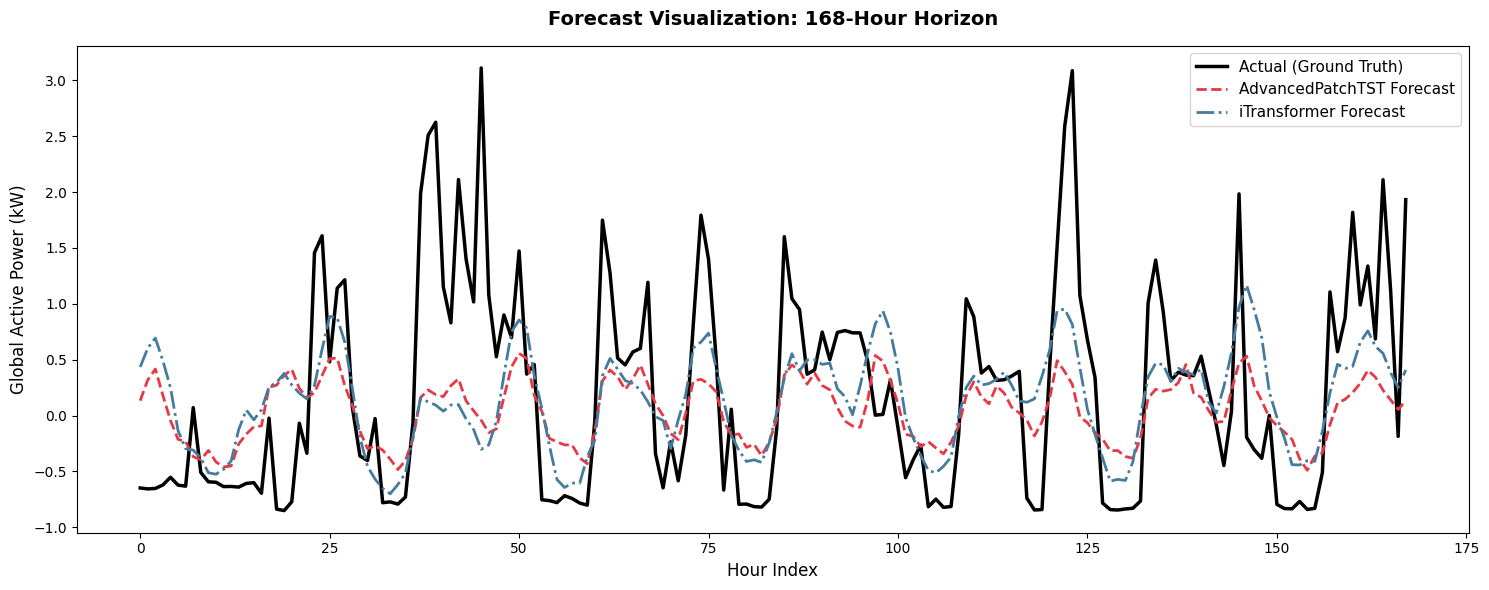

In [8]:
# Visualize 1-Week Forecast
sample_idx = 42

true_seq = actuals_168[sample_idx, :, 0]
patchtst_seq = preds_patch[sample_idx, :, 0]
itrans_seq = preds_itrans[sample_idx, :, 0]

plt.figure(figsize=(15, 6))
plt.plot(true_seq, label="Actual (Ground Truth)", color="black", linewidth=2.5)
plt.plot(patchtst_seq, label="AdvancedPatchTST Forecast", color="#e63946", linestyle="--", linewidth=2)
plt.plot(itrans_seq, label="iTransformer Forecast", color="#457b9d", linestyle="-.", linewidth=2)

plt.title("Forecast Visualization: 168-Hour Horizon", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Hour Index", fontsize=12)
plt.ylabel("Global Active Power (kW)", fontsize=12)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()
